# Visualization

Every way Easy-EO draws a raster, and when to use each.

- **Data:** the bundled Sentinel-2 sample and Copernicus DEM
- **Network:** only for the first download of the sample

Plot functions are **terminal** - they draw and return `None`, so they end a chain rather than continuing it. They also read at *display* resolution rather than pulling the whole array into memory, so previewing a large scene is cheap.

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt

# Keeps the figures stored in this notebook small; raise it for print-quality output.
plt.rcParams["figure.dpi"] = 80

In [2]:
from eeo import load_raster
from eeo.datasets import load_sample_dataset

sd = load_sample_dataset()
scene = load_raster(sd.sentinel2_stacked)
dem = load_raster(sd.copernicus_dem)

## plot_raster - one band as a map

The workhorse. Defaults to the first band; pass a name or index for another.

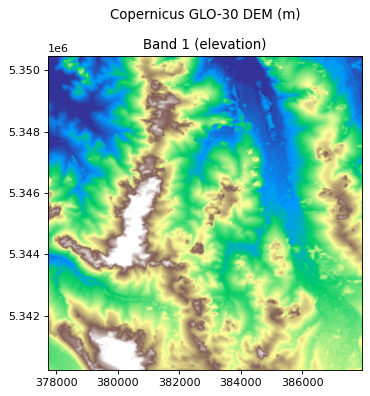

In [3]:
dem.plot_raster(cmap="terrain", title="Copernicus GLO-30 DEM (m)")

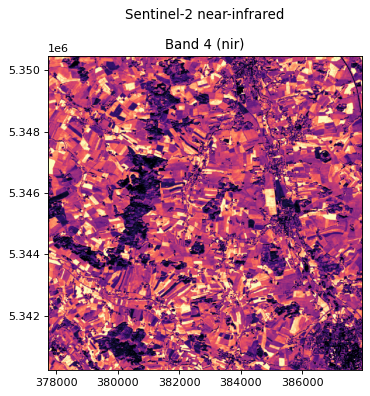

In [4]:
scene.plot_raster("nir", cmap="magma", title="Sentinel-2 near-infrared")

### Stretching

Satellite reflectance is bunched into a narrow part of the available range, so an unstretched image looks flat and dark. `stretch=True` (the default) rescales to the `pmin`–`pmax` percentiles; widen or narrow them to taste.

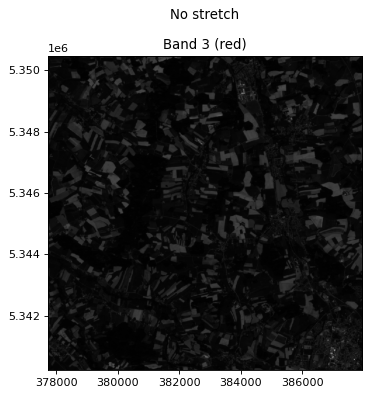

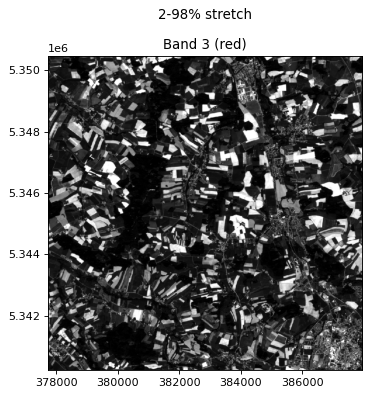

In [5]:
scene.plot_raster("red", stretch=False, cmap="gray", title="No stretch")
scene.plot_raster("red", pmin=2, pmax=98, cmap="gray", title="2-98% stretch")

Any extra keyword goes straight through to Matplotlib's `imshow`, so the full range of Matplotlib control is still available.

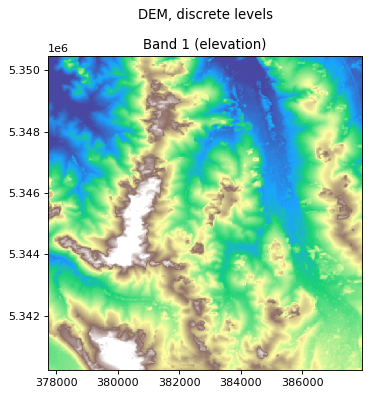

In [6]:
dem.plot_raster(cmap="terrain", title="DEM, discrete levels", interpolation="nearest", alpha=0.9)

## plot_composite - three bands as colour

Give it three bands in red-green-blue order.

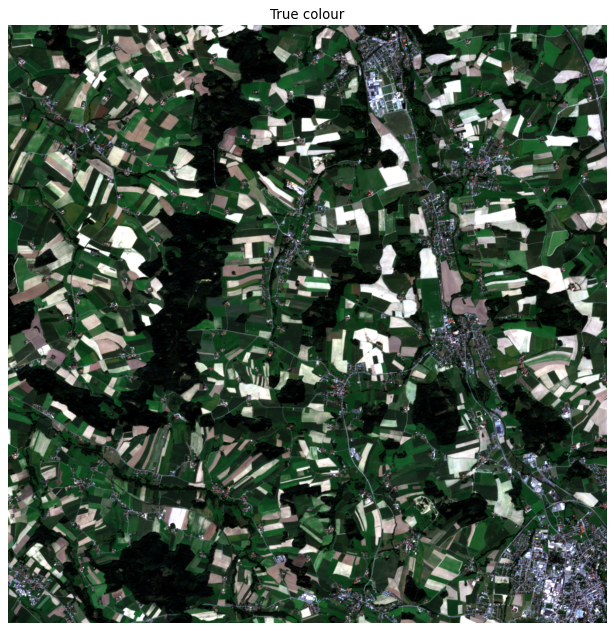

In [7]:
scene.plot_composite(["red", "green", "blue"], pmin=2, pmax=98, title="True colour")

Swapping in the near-infrared band gives the classic false-colour view, where healthy vegetation glows red.

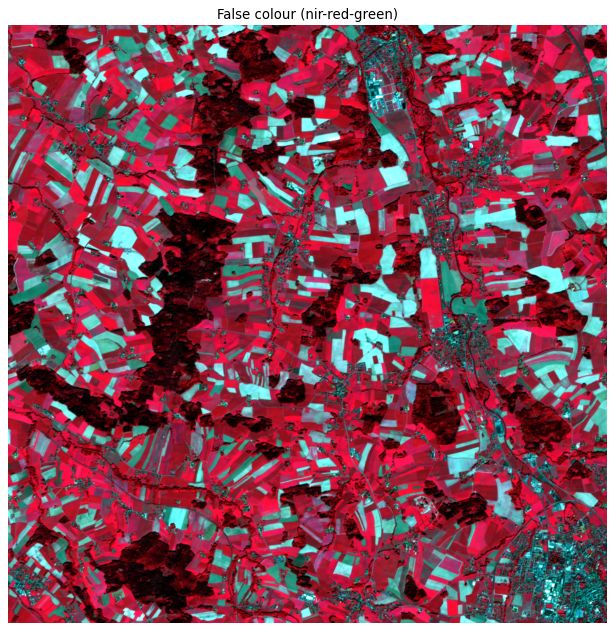

In [8]:
scene.plot_composite(["nir", "red", "green"], pmin=2, pmax=98, title="False colour (nir-red-green)")

## plot_histogram - the distribution

Indispensable before choosing a threshold: it tells you whether the classes you are trying to separate are actually separable.

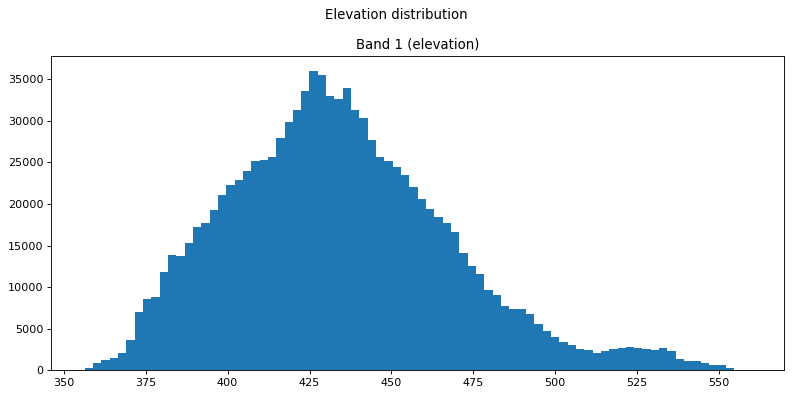

In [9]:
dem.plot_histogram(bins=80, title="Elevation distribution")

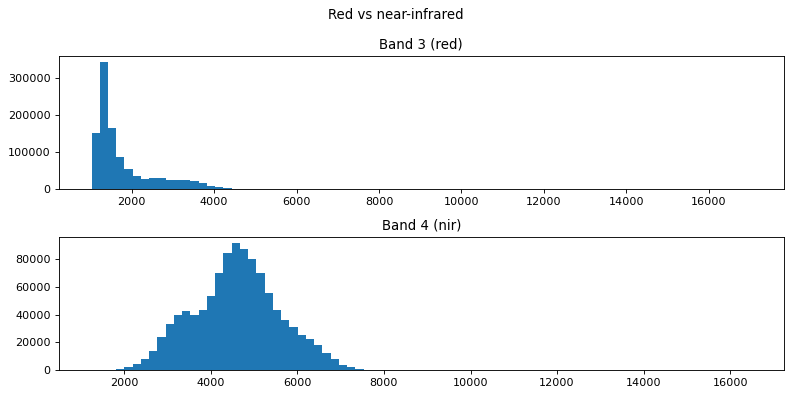

In [10]:
scene.plot_histogram(["red", "nir"], bins=80, title="Red vs near-infrared")

`log=True` rescales the count axis, which rescues a histogram dominated by one huge bin.

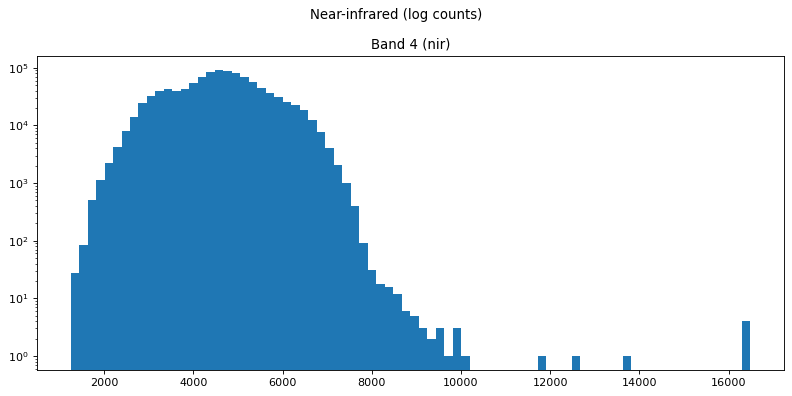

In [11]:
scene.plot_histogram("nir", bins=80, log=True, title="Near-infrared (log counts)")

## plot_raster_with_histogram - both at once

The most useful single view when you are inspecting a new layer: the map tells you *where*, the histogram tells you *how much*.

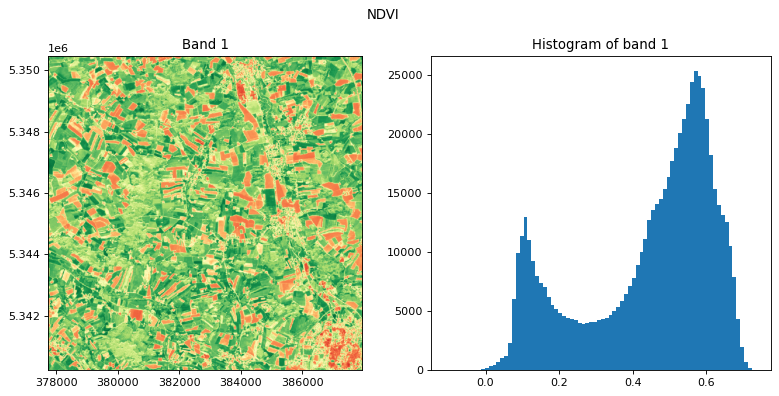

In [12]:
ndvi = scene.ndvi(red="red", nir="nir")
ndvi.plot_raster_with_histogram(cmap="RdYlGn", bins=80, title="NDVI")

## plot_band_array - every band side by side

A quick contact sheet of a multi-band scene.

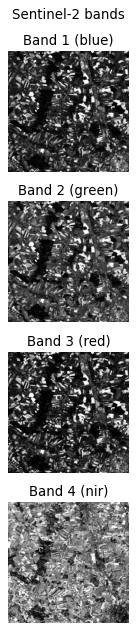

In [13]:
scene.plot_band_array(["blue", "green", "red", "nir"], cmap="gray", pmin=2, pmax=98,
                      title="Sentinel-2 bands")

## Saving a figure

Every plot function takes `save_path`. The figure is written to disk as well as displayed.

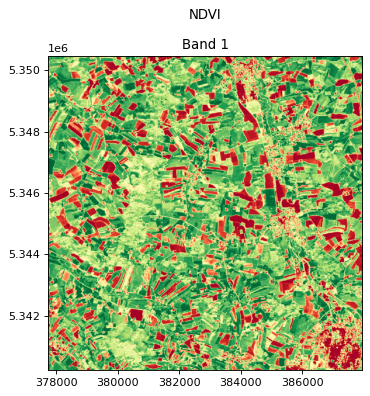

ndvi.png: 3041 KB


In [14]:
import tempfile
from pathlib import Path

out_dir = Path(tempfile.mkdtemp())
ndvi.plot_raster(cmap="RdYlGn", title="NDVI", save_path=str(out_dir / "ndvi.png"))

written = out_dir / "ndvi.png"
print(f"{written.name}: {written.stat().st_size / 1e3:.0f} KB")

## Plotting at the end of a chain

Because plots are terminal, they read naturally as the last step of an expression.

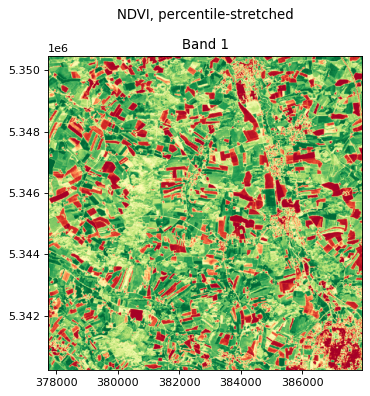

In [15]:
(
    scene.ndvi(red="red", nir="nir")
    .normalize_percentile(lower_percentile=2, upper_percentile=98)
    .plot_raster(cmap="RdYlGn", title="NDVI, percentile-stretched")
)

## Beyond the built-ins

The built-ins cover inspection, not cartography. For anything bespoke, pull the array out and use Matplotlib directly - `get_band` gives you a plain 2D NumPy array, and `get_bounds()` gives you the extent to place it correctly.

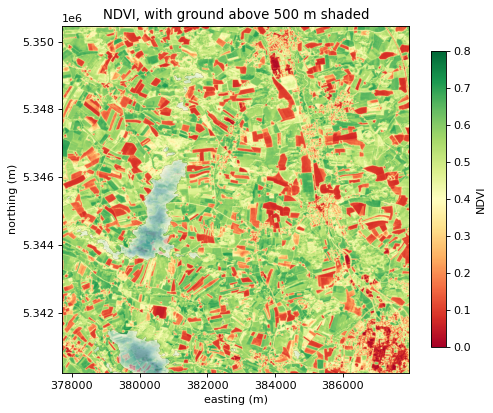

In [16]:
import numpy as np

values = ndvi.get_band(1)
elevation = dem.get_band(1)
bounds = ndvi.get_bounds()
extent = (bounds.left, bounds.right, bounds.bottom, bounds.top)

# mask everything below 500 m, so only the high ground is drawn on top
high_ground = np.ma.masked_where(elevation < 500, elevation)

fig, ax = plt.subplots(figsize=(7, 6))
image = ax.imshow(values, cmap="RdYlGn", vmin=0, vmax=0.8, extent=extent)
ax.imshow(high_ground, cmap="Blues", alpha=0.55, extent=extent)
ax.set_title("NDVI, with ground above 500 m shaded")
ax.set_xlabel("easting (m)")
ax.set_ylabel("northing (m)")
fig.colorbar(image, ax=ax, label="NDVI", shrink=0.8)
plt.show()

Both arrays share a grid here, so they can be overlaid directly. When they do not, put them on a common grid first - see [03_reproject_and_resample](03_reproject_and_resample.ipynb).

In [17]:
for ds in (scene, dem, ndvi):
    ds.close()
print("closed")

closed


## Next

- **[../02_data_access/01_sample_data](../02_data_access/01_sample_data.ipynb)** - the sample data helper in full
- **[../02_data_access/02_stac_search_and_load](../02_data_access/02_stac_search_and_load.ipynb)** - get your own scenes